# Spectral Input Analysis for Maize Condition Classification

## Research Question

Can selected Red Edge and NIR information added to RGB improve maize condition classification, and how reliably can the resulting models distinguish rust disease from water stress?

## Overview

This exploratory study compares different spectral input configurations for classifying five maize conditions:

- Bare soil
- Healthy vegetation
- High water stress
- Low water stress
- Rust disease

A pretrained ResNet18 is evaluated using five input configurations:

- RGB
- RGB + Red Edge
- RGB + NIR
- RGB + Red Edge + NIR
- 6-channel input

To examine training variability, each configuration is trained using three random seeds (42, 123, and 2026) on the same fixed train/validation/test split.

The analysis focuses on two questions:

1. How does spectral input selection affect five-class classification performance?
2. How reliably can the models distinguish rust disease from water-stress conditions?


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import tifffile
from torch.utils.data import Dataset
from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import random
from sklearn.metrics import accuracy_score, f1_score
from torchvision import models
print("PyTorch version:", torch.__version__)

PyTorch version: 2.13.0+cpu


In [ ]:
# Dataset directory
# Download the dataset following the instructions in the repository README
# and place the prepared mini datasets inside the data/ directory.

base_path = Path("../data")

path_3ch = base_path / "mini_dataset_3ch"
path_6ch = base_path / "mini_dataset_6ch"

print("3-channel dataset found:", path_3ch.exists())
print("6-channel dataset found:", path_6ch.exists())


## Dataset and Data Split

This experiment uses a prepared mini dataset containing 750 maize image patches across five classes: bare soil, healthy vegetation, high water stress, low water stress, and rust disease.

The dataset contains 150 samples per class. A stratified split is used to preserve the class distribution:

- Training: 525 images (70%)
- Validation: 112 images (15%)
- Test: 113 images (15%)

The split is fixed using `random_state=42` and is kept identical across all spectral configurations to ensure a fair comparison.

Matching multi-channel images are selected by filename so that each spectral configuration uses exactly the same training, validation, and test samples.


In [3]:
image_paths = []
labels = []
classes = [
    "bare_soil",
    "healthy",
    "high_stress",
    "low_stress",
    "rust"
    
]

for class_name in classes:
    folder = path_3ch / class_name
    for image_path in folder.glob("*.tif"):
        image_paths.append(image_path)
        labels.append(class_name)
        
print("Number of images:", len(image_paths))
print("Number of labels:", len(labels))
        

Number of images: 750
Number of labels: 750


In [10]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, 
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
    
)

print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))

Train: 525
Validation: 112
Test: 113


In [8]:
print("TRAIN")
for class_name in classes:
    print(class_name, ":", train_labels.count(class_name))
print()   

print("VALIDATION")
for class_name in classes:
    print(class_name, ":", val_labels.count(class_name))
print() 

print("TEST")
for class_name in classes:
    print(class_name, ":", test_labels.count(class_name))
print() 
     

TRAIN
bare_soil : 105
healthy : 105
high_stress : 105
low_stress : 105
rust : 105

VALIDATION
bare_soil : 22
healthy : 23
high_stress : 22
low_stress : 22
rust : 23

TEST
bare_soil : 23
healthy : 22
high_stress : 23
low_stress : 23
rust : 22



In [13]:
class_to_number = {
    "bare_soil": 0,
    "healthy": 1,
    "high_stress": 2,
    "low_stress": 3,
    "rust": 4
}

print(class_to_number)

{'bare_soil': 0, 'healthy': 1, 'high_stress': 2, 'low_stress': 3, 'rust': 4}


In [14]:
device = torch.device("cpu")
print("Device:", device)

Device: cpu


In [11]:
def make_6ch_paths(paths_3ch):

    paths_6ch = []

    for path in paths_3ch:

        class_name = path.parent.name
        file_name = path.name

        new_path = path_6ch / class_name / file_name

        paths_6ch.append(new_path)

    return paths_6ch


In [12]:
train_paths_6ch = make_6ch_paths(train_paths)
val_paths_6ch = make_6ch_paths(val_paths)
test_paths_6ch = make_6ch_paths(test_paths)

print("Train:", len(train_paths_6ch))
print("Validation:", len(val_paths_6ch))
print("Test:", len(test_paths_6ch))

Train: 525
Validation: 112
Test: 113


## Model and Spectral Configurations

A pretrained ResNet18 is used as the classification model. The final fully connected layer is replaced to predict the five maize condition classes.

Five input configurations are compared:

- RGB
- RGB + Red Edge
- RGB + NIR
- RGB + Red Edge + NIR
- 6-channel input

For configurations with more than three input channels, the first convolutional layer of ResNet18 is modified to accept the required number of channels. The pretrained ImageNet weights are retained for the RGB channels, while additional channel weights are initialized using the mean of the pretrained RGB weights.

All images are normalized to the range [0, 1]. The same train, validation, and test samples are used for every spectral configuration.

Training settings:

- Model: ResNet18 pretrained on ImageNet
- Optimizer: Adam
- Learning rate: 0.0001
- Batch size: 32
- Epochs: 5
- Number of classes: 5


In [15]:
class MaizeBandDataset(Dataset):

    def __init__(self, image_paths, labels, channels):
        self.image_paths = image_paths
        self.labels = labels
        self.channels = channels

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):

        image = tifffile.imread(
            self.image_paths[index]
        )

        # Select requested bands
        image = image[:, :, self.channels]

        image = image.astype(np.float32) / 255.0

        # HWC -> CHW
        image = np.transpose(image, (2, 0, 1))

        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        label = class_to_number[
            self.labels[index]
        ]

        return image, label


In [17]:
def prepare_experiment(channels):

    # Datasets
    train_dataset = MaizeBandDataset(
        train_paths_6ch,
        train_labels,
        channels
    )

    val_dataset = MaizeBandDataset(
        val_paths_6ch,
        val_labels,
        channels
    )

    test_dataset = MaizeBandDataset(
        test_paths_6ch,
        test_labels,
        channels
    )

    # DataLoaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=32,
        shuffle=False
    )

    # ResNet18
    model = models.resnet18(
        weights=models.ResNet18_Weights.DEFAULT
    )

    old_conv = model.conv1
    num_channels = len(channels)

    # Change first layer when input is not 3 channels
    if num_channels != 3:

        model.conv1 = nn.Conv2d(
            num_channels,
            64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )

        with torch.no_grad():

            # RGB pretrained weights
            model.conv1.weight[:, :3] = old_conv.weight

            # Extra channel(s)
            mean_weight = old_conv.weight.mean(
                dim=1,
                keepdim=True
            )

            for i in range(3, num_channels):
                model.conv1.weight[:, i:i+1] = mean_weight

    # 5 classes
    model.fc = nn.Linear(
        model.fc.in_features,
        5
    )

    model = model.to(device)

    return model, train_loader, val_loader, test_loader


## Repeated Experiments

To examine the effect of training randomness, each spectral configuration is trained three times using different random seeds:

- 42
- 123
- 2026

The train, validation, and test split remains fixed across all runs. Therefore, the variation across seeds reflects training stochasticity rather than variation caused by different dataset splits.

Each model is trained for five epochs using the same training settings. Predictions for all 113 test images are saved for every run.

In total, the experiment consists of 15 training runs:

**5 spectral configurations × 3 training seeds = 15 runs**

The saved predictions are subsequently used for both the five-class performance evaluation and the disease-versus-water-stress analysis.


In [24]:
# ==========================================
# Repeated experiments + save predictions
# ==========================================

experiments = {
    "RGB": [0, 1, 2],
    "RGB + Red Edge": [0, 1, 2, 3],
    "RGB + NIR": [0, 1, 2, 4],
    "RGB + Red Edge + NIR": [0, 1, 2, 3, 4],
    "6-Channel": [0, 1, 2, 3, 4, 5]
}

seeds = [42, 123, 2026]

saved_predictions = []

for seed in seeds:

    print("\n################################")
    print("SEED:", seed)
    print("################################")

    for experiment_name, channels in experiments.items():

        print("\n----------------------------")
        print("Model:", experiment_name)
        print("----------------------------")

        # Set seed
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        # Prepare model and data
        model, train_loader, val_loader, test_loader = prepare_experiment(
            channels
        )

        criterion = nn.CrossEntropyLoss()

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=0.0001
        )

        # =====================
        # Training
        # =====================

        for epoch in range(5):

            model.train()

            correct = 0
            total = 0
            running_loss = 0.0

            for images, labels_batch in train_loader:

                images = images.to(device)
                labels_batch = labels_batch.to(device)

                optimizer.zero_grad()

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels_batch
                )

                loss.backward()

                optimizer.step()

                running_loss += loss.item()

                predictions = outputs.argmax(dim=1)

                total += labels_batch.size(0)

                correct += (
                    predictions == labels_batch
                ).sum().item()

            train_accuracy = correct / total

            average_loss = (
                running_loss / len(train_loader)
            )

            print(
                f"Epoch {epoch+1}/5 | "
                f"Loss: {average_loss:.4f} | "
                f"Train Accuracy: {train_accuracy:.4f}"
            )

        # =====================
        # Test predictions
        # =====================

        model.eval()

        true_labels = []
        predicted_labels = []

        with torch.no_grad():

            for images, labels_batch in test_loader:

                images = images.to(device)

                outputs = model(images)

                predictions = outputs.argmax(dim=1)

                true_labels.extend(
                    labels_batch.cpu().tolist()
                )

                predicted_labels.extend(
                    predictions.cpu().tolist()
                )

        # Save every test prediction
        for true_label, predicted_label in zip(
            true_labels,
            predicted_labels
        ):

            saved_predictions.append({
                "Seed": seed,
                "Model": experiment_name,
                "True Label": true_label,
                "Predicted Label": predicted_label
            })

        print(
            "Saved test predictions:",
            len(true_labels)
        )


print("\nFINISHED")
print(
    "Total saved predictions:",
    len(saved_predictions)
)



################################
SEED: 42
################################

----------------------------
Model: RGB
----------------------------
Epoch 1/5 | Loss: 0.7293 | Train Accuracy: 0.7600
Epoch 2/5 | Loss: 0.1198 | Train Accuracy: 0.9714
Epoch 3/5 | Loss: 0.0482 | Train Accuracy: 0.9924
Epoch 4/5 | Loss: 0.0278 | Train Accuracy: 0.9962
Epoch 5/5 | Loss: 0.0172 | Train Accuracy: 1.0000
Saved test predictions: 113

----------------------------
Model: RGB + Red Edge
----------------------------
Epoch 1/5 | Loss: 0.7426 | Train Accuracy: 0.7524
Epoch 2/5 | Loss: 0.1044 | Train Accuracy: 0.9810
Epoch 3/5 | Loss: 0.0480 | Train Accuracy: 0.9905
Epoch 4/5 | Loss: 0.0263 | Train Accuracy: 0.9962
Epoch 5/5 | Loss: 0.0159 | Train Accuracy: 1.0000
Saved test predictions: 113

----------------------------
Model: RGB + NIR
----------------------------
Epoch 1/5 | Loss: 0.7436 | Train Accuracy: 0.7524
Epoch 2/5 | Loss: 0.1004 | Train Accuracy: 0.9810
Epoch 3/5 | Loss: 0.0510 | Train Accuracy

## Disease vs Water-Stress Analysis

A task-specific analysis is performed to evaluate how reliably the trained models distinguish rust disease from water-stress conditions.

This analysis includes the 68 test samples whose true labels are:

- Rust: 22 samples
- High water stress: 23 samples
- Low water stress: 23 samples

A prediction is counted as correct only when:

- A true rust sample is predicted as rust.
- A true water-stress sample is predicted as either high stress or low stress.

Predictions of healthy vegetation or bare soil are counted as errors.

This analysis uses the predictions produced by the original five-class models. No separate binary classifier is trained.

Across the three training seeds, the **RGB + Red Edge + NIR** configuration achieved the highest mean task-specific accuracy:

**99.51 ± 0.85%**

These results indicate strong disease-versus-water-stress discrimination on this fixed test subset. However, they should be interpreted within the limitations of the small prepared dataset and fixed data split.


In [ ]:
# ==========================================
# Final Disease vs Water-Stress Evaluation
# ==========================================

predictions_df = pd.DataFrame(saved_predictions)

RUST = 4
HIGH_STRESS = 2
LOW_STRESS = 3

final_disease_stress_results = []

for seed in seeds:

    for model_name in experiments.keys():

        df = predictions_df[
            (predictions_df["Seed"] == seed) &
            (predictions_df["Model"] == model_name)
        ].copy()

        # Only samples whose TRUE condition is
        # Rust or Water Stress
        df = df[
            df["True Label"].isin([
                RUST,
                HIGH_STRESS,
                LOW_STRESS
            ])
        ].copy()

        correct = 0

        for _, row in df.iterrows():

            true_label = row["True Label"]
            predicted_label = row["Predicted Label"]

            # True Rust must be predicted as Rust
            if true_label == RUST:

                if predicted_label == RUST:
                    correct += 1

            # True Water Stress must be predicted
            # as either Low Stress or High Stress
            else:

                if predicted_label in [
                    HIGH_STRESS,
                    LOW_STRESS
                ]:
                    correct += 1

        accuracy = correct / len(df)

        final_disease_stress_results.append({
            "Seed": seed,
            "Model": model_name,
            "Correct": correct,
            "Total": len(df),
            "Disease vs Water Stress Accuracy": accuracy
        })


final_disease_stress_df = pd.DataFrame(
    final_disease_stress_results
)

display(
    final_disease_stress_df.round(4)
)


In [28]:
final_binary_summary = (
    final_disease_stress_df
    .groupby("Model")["Disease vs Water Stress Accuracy"]
    .agg(["mean", "std"])
    .reset_index()
)

final_binary_summary["mean"] *= 100
final_binary_summary["std"] *= 100

final_binary_summary.columns = [
    "Model",
    "Mean Accuracy (%)",
    "SD (%)"
]

display(
    final_binary_summary.round(2)
)


,Model,Mean Accuracy (%),SD (%)
0,6-Channel,98.04,0.85
1,RGB,97.55,1.70
2,RGB + NIR,98.04,1.70
3,RGB + Red Edge,98.04,1.70
4,RGB + Red Edge + NIR,99.51,0.85


## Five-Class Classification Results

Performance is evaluated on the fixed test set using accuracy and macro F1-score. The reported values represent the mean and standard deviation across the three training seeds.

Among the evaluated configurations, **RGB + Red Edge + NIR** achieved the highest mean test performance:

- Accuracy: **98.23 ± 0.88%**
- Macro F1-score: **98.21 ± 0.90%**

For comparison, the RGB baseline achieved:

- Accuracy: **96.76 ± 0.51%**
- Macro F1-score: **96.75 ± 0.52%**

The 6-channel input achieved an accuracy of **97.05 ± 0.51%**, indicating that adding more input channels did not monotonically improve classification performance in these experiments.

The results therefore suggest that spectral-band selection may be more useful than simply increasing the number of input channels for this dataset and experimental setting.


In [29]:
# ==========================================
# Five-Class Classification Summary
# Mean ± SD across 3 seeds
# ==========================================

predictions_df = pd.DataFrame(saved_predictions)

five_class_results = []

for seed in seeds:

    for model_name in experiments.keys():

        df = predictions_df[
            (predictions_df["Seed"] == seed) &
            (predictions_df["Model"] == model_name)
        ]

        accuracy = accuracy_score(
            df["True Label"],
            df["Predicted Label"]
        )

        macro_f1 = f1_score(
            df["True Label"],
            df["Predicted Label"],
            average="macro"
        )

        five_class_results.append({
            "Seed": seed,
            "Model": model_name,
            "Accuracy": accuracy,
            "Macro F1": macro_f1
        })


five_class_df = pd.DataFrame(five_class_results)


# Mean and SD across the 3 seeds
five_class_summary = (
    five_class_df
    .groupby("Model")
    .agg({
        "Accuracy": ["mean", "std"],
        "Macro F1": ["mean", "std"]
    })
    .reset_index()
)


five_class_summary.columns = [
    "Model",
    "Accuracy Mean (%)",
    "Accuracy SD (%)",
    "Macro F1 Mean (%)",
    "Macro F1 SD (%)"
]


for column in [
    "Accuracy Mean (%)",
    "Accuracy SD (%)",
    "Macro F1 Mean (%)",
    "Macro F1 SD (%)"
]:
    five_class_summary[column] *= 100


display(
    five_class_summary.round(2)
)


,Model,Accuracy Mean (%),Accuracy SD (%),Macro F1 Mean (%),Macro F1 SD (%)
0,6-Channel,97.05,0.51,97.02,0.55
1,RGB,96.76,0.51,96.75,0.52
2,RGB + NIR,97.64,0.51,97.62,0.50
3,RGB + Red Edge,97.05,0.51,97.03,0.48
4,RGB + Red Edge + NIR,98.23,0.88,98.21,0.90


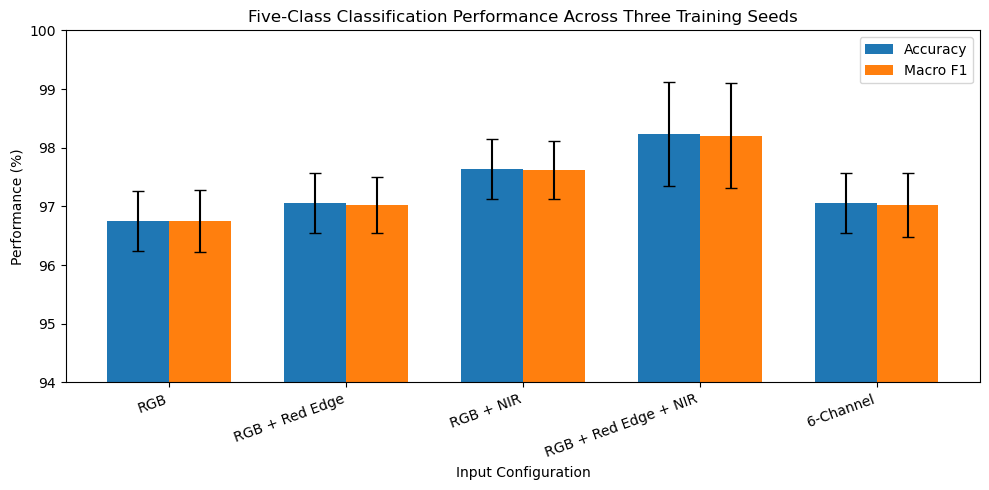

In [30]:
# ==========================================
# Final Five-Class Performance Plot
# ==========================================

plot_data = five_class_summary.copy()

# Keep the same logical order as the experiments
model_order = [
    "RGB",
    "RGB + Red Edge",
    "RGB + NIR",
    "RGB + Red Edge + NIR",
    "6-Channel"
]

plot_data["Model"] = pd.Categorical(
    plot_data["Model"],
    categories=model_order,
    ordered=True
)

plot_data = plot_data.sort_values("Model")


x = np.arange(len(plot_data))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    x - width / 2,
    plot_data["Accuracy Mean (%)"],
    width,
    yerr=plot_data["Accuracy SD (%)"],
    capsize=4,
    label="Accuracy"
)

ax.bar(
    x + width / 2,
    plot_data["Macro F1 Mean (%)"],
    width,
    yerr=plot_data["Macro F1 SD (%)"],
    capsize=4,
    label="Macro F1"
)

ax.set_ylabel("Performance (%)")
ax.set_xlabel("Input Configuration")

ax.set_title(
    "Five-Class Classification Performance Across Three Training Seeds"
)

ax.set_xticks(x)

ax.set_xticklabels(
    plot_data["Model"],
    rotation=20,
    ha="right"
)

ax.set_ylim(94, 100)

ax.legend()

plt.tight_layout()
plt.show()


## Discussion, Limitations, and Conclusion

Across the three training seeds, the **RGB + Red Edge + NIR** configuration achieved the highest mean five-class classification performance, with **98.23 ± 0.88% accuracy** and **98.21 ± 0.90% macro F1-score**.

The same configuration also achieved the highest mean accuracy in the disease-versus-water-stress analysis (**99.51 ± 0.85%**). These results suggest that combining RGB with selected Red Edge and NIR information can provide useful complementary information for maize condition classification in this dataset. Importantly, increasing the number of input channels did not consistently improve performance, since the 6-channel input did not outperform the selected RGB + Red Edge + NIR configuration.

### Limitations

This study is exploratory and has several important limitations:

- The experiment uses a small prepared dataset containing 750 image patches.
- The fixed test set contains only 113 images, including 68 samples relevant to the disease-versus-water-stress analysis.
- The reported standard deviations are based on three training seeds using the same fixed data split. They therefore represent training variability rather than variability across independent dataset splits.
- The prepared mini dataset was pooled from the original source partitions before the train/validation/test split used in this experiment. Therefore, source independence is not guaranteed.
- The evaluation uses a random patch-level split rather than an independent field-, flight-, or scene-level test set.
- The 6-channel input includes an alpha channel and should not be interpreted as six spectral bands.
- The near-perfect disease-versus-water-stress performance should not be interpreted as real-world field accuracy.

### Conclusion

Within this exploratory experimental setting, **RGB + Red Edge + NIR** produced the highest mean performance among the evaluated input configurations.

The findings provide preliminary evidence that selecting complementary spectral information may be more useful than simply increasing the number of input channels. Further experiments using independent source-level or field-level datasets are needed to determine whether these findings generalize to more realistic agricultural remote-sensing conditions.
